<a href="https://colab.research.google.com/github/mudithabatuwangala/robust-gnn/blob/balpreetb%2Ftest-mutag/Trial_1_Mutag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision torchaudio torch-geometric matplotlib networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.7 MB/s eta 0:00:00


In [ ]:
from torch_geometric.datasets import TUDataset

# Load the MUTAG dataset
dataset = TUDataset(root='/tmp/MUTAG', name='MUTAG')

print("Number of graphs:", len(dataset))
print("Number of classes:", dataset.num_classes)
print("Number of node features:", dataset.num_node_features)

# Look at the first molecule
data = dataset[0]
data

Number of graphs: 188
Number of classes: 2
Number of node features: 7


Processing...
Done!


Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])

Molecule 0, nodes: 17, edges: 38, label: 1


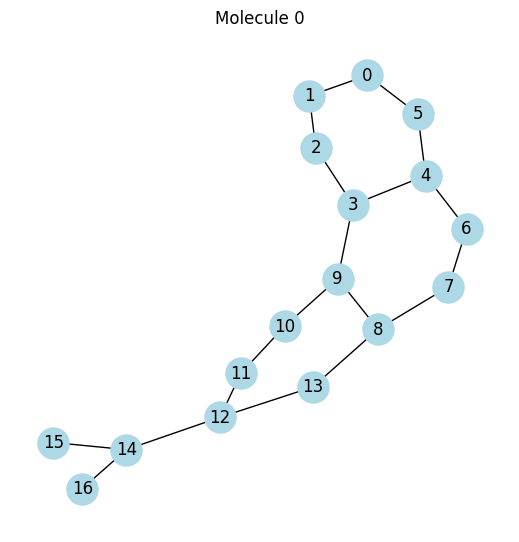

Molecule 1, nodes: 13, edges: 28, label: 0


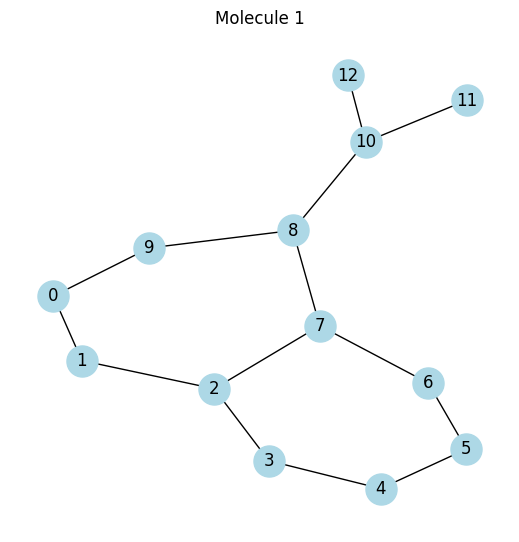

Molecule 2, nodes: 13, edges: 28, label: 0


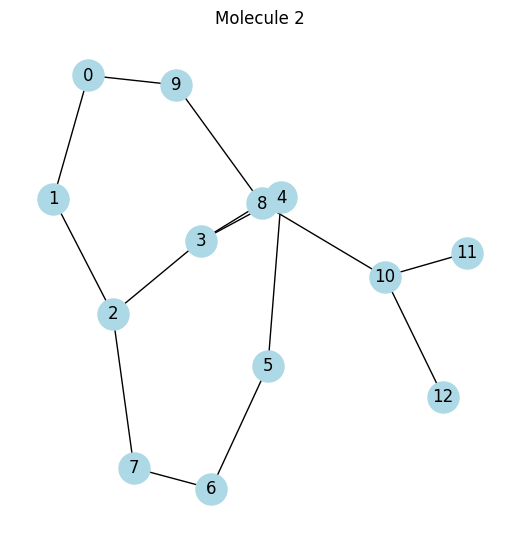

Molecule 3, nodes: 19, edges: 44, label: 1


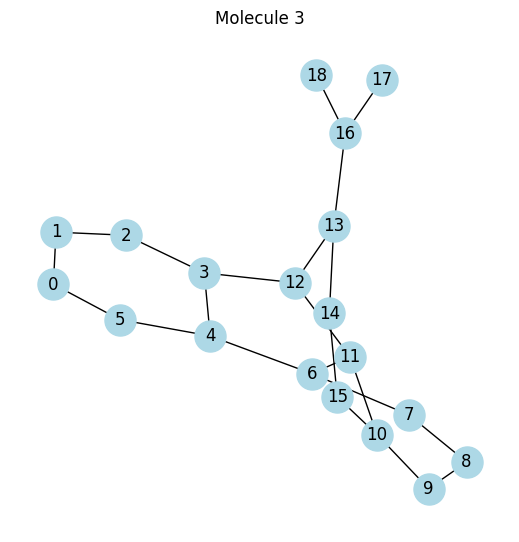

Molecule 4, nodes: 11, edges: 22, label: 0


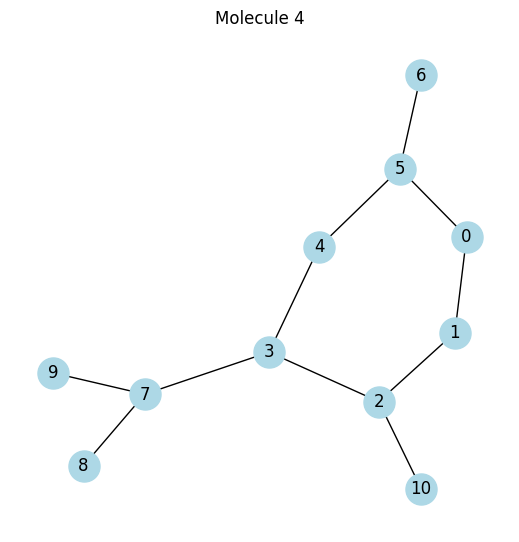

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

for idx in range(5):  # first 5 molecules
    data = dataset[idx]  # select the molecule

    print(f"Molecule {idx}, nodes: {data.x.shape[0]}, edges: {data.edge_index.shape[1]}, label: {data.y.item()}")

    # Convert edge_index to networkx graph
    G = nx.Graph()
    edge_index = data.edge_index.numpy()
    for j in range(edge_index.shape[1]):
        src = edge_index[0, j]
        tgt = edge_index[1, j]
        G.add_edge(src, tgt)

    # Draw the graph
    plt.figure(figsize=(5,5))
    nx.draw(G, with_labels=True, node_color='lightblue', node_size=500)
    plt.title(f"Molecule {idx}")
    plt.show()

In [ ]:
from torch_geometric.loader import DataLoader

# Split dataset into train and test (80/20)
train_dataset = dataset[:150]  # first 150 molecules
test_dataset = dataset[150:]   # remaining 38 molecules

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)  # combine node features to graph-level
        x = self.lin(x)
        return x

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GCN(
    in_channels=dataset.num_node_features,
    hidden_channels=64,
    out_channels=dataset.num_classes
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
def train():
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

for epoch in range(1, 21):
    loss = train()
    print(f'Epoch {epoch}, Loss: {loss:.4f}')

Epoch 1, Loss: 0.6477
Epoch 2, Loss: 0.6215
Epoch 3, Loss: 0.6081
Epoch 4, Loss: 0.6078
Epoch 5, Loss: 0.5796
Epoch 6, Loss: 0.5687
Epoch 7, Loss: 0.5472
Epoch 8, Loss: 0.5189
Epoch 9, Loss: 0.5328
Epoch 10, Loss: 0.5196
Epoch 11, Loss: 0.5171
Epoch 12, Loss: 0.5088
Epoch 13, Loss: 0.5217
Epoch 14, Loss: 0.4922
Epoch 15, Loss: 0.5021
Epoch 16, Loss: 0.4966
Epoch 17, Loss: 0.5035
Epoch 18, Loss: 0.5090
Epoch 19, Loss: 0.4998
Epoch 20, Loss: 0.5096


In [ ]:
def test(loader):
    model.eval()
    correct = 0
    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        pred = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
    return correct / len(loader.dataset)

acc = test(test_loader)
print(f'Test Accuracy: {acc:.4f}')

Test Accuracy: 0.7368


In [ ]:
model.eval()  # switch to evaluation mode
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        preds = out.argmax(dim=1)  # get class with highest score
        all_preds.append(preds.cpu())
        all_labels.append(batch.y.cpu())

# Combine all batches
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

print("Predictions:", all_preds)
print("True labels:", all_labels)

Predictions: tensor([0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
        0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1])
True labels: tensor([1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
        0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0])


In [ ]:
for i in range(len(all_preds)):
    print(f"Molecule {i}: Predicted = {all_preds[i].item()}, True = {all_labels[i].item()}")

Molecule 0: Predicted = 0, True = 1
Molecule 1: Predicted = 1, True = 1
Molecule 2: Predicted = 1, True = 1
Molecule 3: Predicted = 0, True = 0
Molecule 4: Predicted = 0, True = 0
Molecule 5: Predicted = 0, True = 0
Molecule 6: Predicted = 1, True = 1
Molecule 7: Predicted = 1, True = 1
Molecule 8: Predicted = 1, True = 1
Molecule 9: Predicted = 0, True = 0
Molecule 10: Predicted = 1, True = 1
Molecule 11: Predicted = 1, True = 1
Molecule 12: Predicted = 1, True = 1
Molecule 13: Predicted = 1, True = 1
Molecule 14: Predicted = 1, True = 1
Molecule 15: Predicted = 1, True = 1
Molecule 16: Predicted = 1, True = 1
Molecule 17: Predicted = 1, True = 0
Molecule 18: Predicted = 0, True = 1
Molecule 19: Predicted = 0, True = 1
Molecule 20: Predicted = 1, True = 1
Molecule 21: Predicted = 0, True = 1
Molecule 22: Predicted = 1, True = 1
Molecule 23: Predicted = 1, True = 1
Molecule 24: Predicted = 0, True = 0
Molecule 25: Predicted = 1, True = 1
Molecule 26: Predicted = 0, True = 1
Molecule 27